In [ ]:
!pip install wordcloud
!pip install nltk
!pip install collection

In [7]:
# Bibliotecas usadas para a análise de dados

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [3]:
dados = pd.read_csv('/content/Closed Tickets - 20240103.csv', sep=';')

In [4]:
dados.head()

,Número do Ticket,Data de Criação,Assunto,De,E-mail de Origem,Prioridade,Departamento,Tópico de ajuda,Origem,Status Atual,...,Atrasado,Merged,Linked,Respondidos,Agente Atribuído,Equipe Atribuída,Contagem da discussão,Reopen Count,Contagem de anexo,Task Count
0,422971,2023-12-28 19:04:09,Cadastro de usuario,Reabilitar Saúde,sreabilitar@gmail.com,Normal,Suporte,TI - Cadastro de Usuário,Web,Resolvido,...,Não,Não,Não,Sim,Igor Simões,NaN,2.0,NaN,NaN,NaN
1,872198,2023-12-26 17:49:45,ANALISE FINANCEIRA,Lidiane Sebadelhe,gr.contasmedicas@hospitalresidencial.com.br,Normal,Suporte,TI - Problema no IW,Web,Resolvido,...,Não,Não,Não,Sim,Marieliton Barbosa,NaN,2.0,NaN,NaN,NaN
2,118625,2024-01-03 10:50:30,ATIVAÇÃO DO WINDOWS,Joacil Junior,centralderegulacao@hospitalmilagres.com.br,Normal,Suporte,TI - Problema de Software,Web,Resolvido,...,Não,Não,Não,Sim,Carlos Lira,NaN,2.0,NaN,NaN,NaN
3,528259,2024-01-02 19:39:30,inclusão de assinatura e carimbo na prescrição...,Conceição Maranhão,auditoria.pb@hospitalmilagres.com.br,Normal,Suporte,TI - Problema no IW,Web,Resolvido,...,Não,Não,Não,Sim,Marieliton Barbosa,NaN,2.0,NaN,NaN,NaN
4,991737,2024-01-03 09:20:51,Painel IW,Aline Francisca,aux.enfermagem@hospitalresidencial.com.br,Normal,Suporte,TI - Outros,Web,Resolvido,...,Não,Não,Não,Sim,Sara Silva,NaN,2.0,NaN,NaN,NaN


In [5]:
dados['Agente Atribuído'].value_counts()

Marieliton Barbosa    3977
Carlos Lira           1921
Jeilson Soares        1223
Mattheus Jordão        972
Sara Silva             515
Sttewart David         251
Igor Simões            128
Diego Cavalcante        56
Paulo de Tarso          50
Name: Agente Atribuído, dtype: int64

In [6]:
dados['De'].value_counts()

Eurides Gomes                388
Jéssica Pereira              361
Nayara Sotero                322
Departamento Pessoal         315
Eduarda Silva                314
                            ... 
Alice Meireles                 1
Elayne Cristina                1
LIDINEA LIMA                   1
Leandro                        1
Darley Fernandes de souza      1
Name: De, Length: 278, dtype: int64

In [17]:
dados['Tópico de ajuda'].value_counts()

TI - Outros                                        3363
TI - Cadastro de Usuário                           2858
TI - Problema no IW                                1181
TI - Email                                          405
TI - Problema de Equipamento                        370
TI - Problema na Impressora                         310
TI - Relatórios                                     182
TI - Reset de Senha                                 177
TI - Treinamento - (desativado)                      85
Pbfoods - Geral                                      66
TI - Dúvidas                                         52
TI - PBFoods                                         50
TI - Problema de Software                            41
TI - Problema no WFS                                 24
Farmácia - Cadastro de Fornecedo                      7
TI - Segurança da Informação                          6
Contas Médicas - Tópicos Gerais                       3
Transporte - Novo Usuário - (desativado)        

In [8]:
# eliminar as colunas com valores ausentes
assunto = dados.dropna(subset=['Assunto'], axis=0)['Assunto']

In [9]:
# concatenar as palavras
assuntos = " ".join(s for s in assunto)

# ver quantidade de palavras
print("Quantidade de Palavras: {}".format(len(assuntos)))

Quantidade de Palavras: 215016


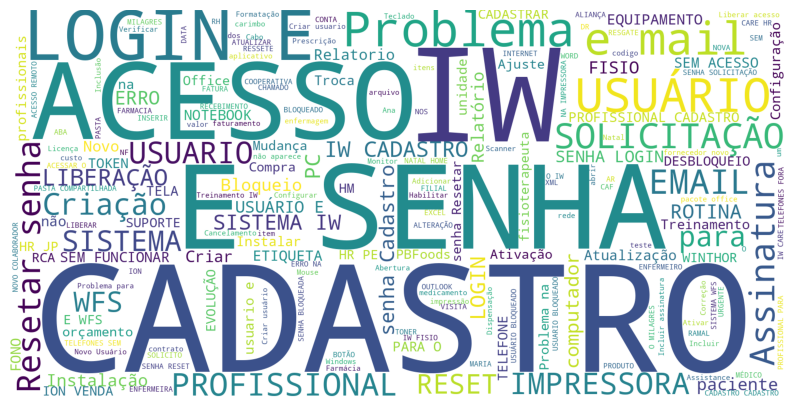

In [11]:
# lista de stopword
stopwords = set(STOPWORDS)
stopwords.update(["da", "meu", "em", "você", "de", "ao", "os" "e"])

# gerar uma wordcloud
wordcloud = WordCloud(stopwords=stopwords,
                      background_color="white",
                      width=1600, height=800).generate(assuntos)

# mostrar a imagem final
fig, ax = plt.subplots(figsize=(10,6))
ax.imshow(wordcloud, interpolation='bilinear')
ax.set_axis_off()

plt.imshow(wordcloud);
wordcloud.to_file("nuvem-de-palavras-assunto.png")